# Starting Kit — Formation Energy Prediction for Materials

This notebook is a **complete, ready-to-run starting kit** built from only two files:
- `X_data_ragged.npy`
- `y_data.npy`

It covers:
1. dataset loading,
2. exploratory data analysis,
3. challenge evaluation design,
4. grouped splitting strategy,
5. a working baseline model,
6. the `submission.py` format for Codabench.


## 1. Challenge introduction

### Scientific context
Predicting the formation energy of a material is useful for screening candidate structures before expensive quantum calculations.
Here, each sample is a small atomic structure with 3D coordinates, and the target is a continuous energy value.

### Task
This challenge is naturally a **regression** problem:
- **input**: an atomic structure (`Z`, `coords`, `nom`),
- **output**: a real-valued target interpreted as a formation-energy-like quantity.

### Why this task is interesting
- the structures have variable size,
- the data mixes chemistry and geometry,
- a simple baseline already works, but there is clear room for stronger graph/materials models.


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn  # imported early to avoid the NumPy pickle compatibility issue
from pathlib import Path

from materials_utils import load_raw_data, build_feature_table, get_numeric_feature_columns, make_group_splits
from submission import get_model

pd.set_option('display.max_columns', 200)
plt.rcParams['figure.figsize'] = (7, 4)

DATA_DIR = Path('.')
X_PATH = DATA_DIR / 'X_data_ragged.npy'
Y_PATH = DATA_DIR / 'y_data.npy'


## 2. Load the raw data

In [2]:
X, y = load_raw_data(X_PATH, Y_PATH)
print('Number of structures:', len(X))
print('Target shape:', y.shape)
print('Target dtype:', y.dtype)
print('One raw structure type:', type(X[0]))
print('Fields:', X[0].dtype.names)
print('\nExample structure:\n', X[0])

Number of structures: 10000
Target shape: (10000,)
Target dtype: float64
One raw structure type: <class 'numpy.ndarray'>
Fields: ('Z', 'coords', 'nom')

Example structure:
 [(89., [ 2.6219237,  0.       ,  0.       ], 'Ac')
 (89., [ 0.6903661, -1.1957493,  3.2679486], 'Ac')
 (89., [ 0.6903661,  1.1957493,  6.5359073], 'Ac')]


## 3. Convert raw ragged structures into tabular features

To make EDA and baseline modeling easier, we derive simple descriptors from each structure:
- number of atoms,
- number of unique elements,
- atomic-number statistics,
- geometric spans,
- simple pairwise-distance statistics,
- element counts.


In [3]:
df, elements = build_feature_table(X)
df['target'] = y
print('Feature table shape:', df.shape)
print('Number of distinct elements:', len(elements))
print(df.head())

Feature table shape: (10000, 102)
Number of distinct elements: 82
   formula  n_atoms  n_unique_elements  z_mean      z_std  z_min  z_max  \
0      Ac3      3.0                1.0   89.00   0.000000   89.0   89.0   
1      Ac3      3.0                1.0   89.00   0.000000   89.0   89.0   
2      Ac4      4.0                1.0   89.00   0.000000   89.0   89.0   
3  Ac2AgIr      4.0                3.0   75.50  17.168285   47.0   89.0   
4  Ac2AgPb      4.0                3.0   76.75  17.412280   47.0   89.0   

   z_sum    span_x    span_y    span_z  bbox_volume_proxy  radius_mean  \
0  267.0  1.931558  2.391499  6.535907          30.191429     2.803163   
1  267.0  4.046861  2.336453  6.538453          61.823023     3.330234   
2  356.0  2.023023  2.335987  9.762777          46.136494     3.566237   
3  302.0  5.707155  5.707155  5.707155         185.891296     3.295023   
4  307.0  6.100844  6.100844  6.100844         227.075218     3.522324   

   radius_std  radius_max  dist_min  d

## 4. Basic descriptive statistics

In [4]:
summary = pd.Series({
    'n_samples': len(df),
    'target_min': float(df['target'].min()),
    'target_mean': float(df['target'].mean()),
    'target_median': float(df['target'].median()),
    'target_max': float(df['target'].max()),
    'target_std': float(df['target'].std()),
    'atoms_min': int(df['n_atoms'].min()),
    'atoms_mean': float(df['n_atoms'].mean()),
    'atoms_median': float(df['n_atoms'].median()),
    'atoms_max': int(df['n_atoms'].max()),
    'n_unique_formulas': int(df['formula'].nunique()),
    'n_distinct_elements': int(len(elements)),
})
summary

n_samples              10000.000000
target_min                -5.153568
target_mean               -1.343933
target_median             -1.367468
target_max                 5.474543
target_std                 1.345092
atoms_min                  2.000000
atoms_mean                11.116400
atoms_median              10.000000
atoms_max                 20.000000
n_unique_formulas       7806.000000
n_distinct_elements       82.000000
dtype: float64

## 5. Exploratory data analysis

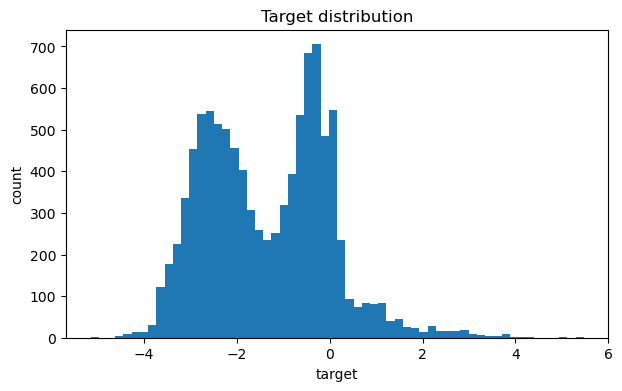

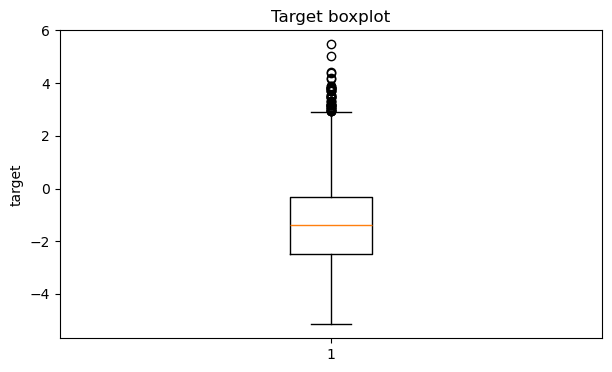

In [5]:
fig, ax = plt.subplots()
ax.hist(df['target'], bins=60)
ax.set_title('Target distribution')
ax.set_xlabel('target')
ax.set_ylabel('count')
plt.show()

fig, ax = plt.subplots()
ax.boxplot(df['target'], vert=True)
ax.set_title('Target boxplot')
ax.set_ylabel('target')
plt.show()

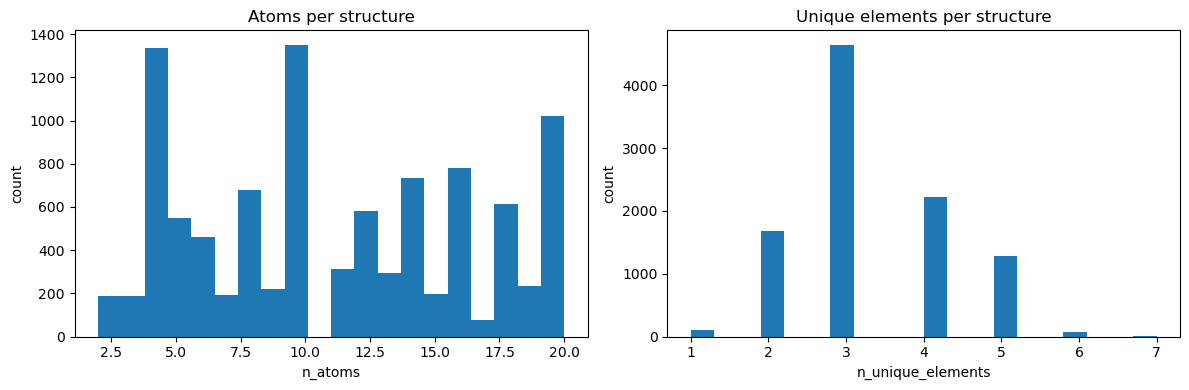

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['n_atoms'], bins=20)
axes[0].set_title('Atoms per structure')
axes[0].set_xlabel('n_atoms')
axes[0].set_ylabel('count')

axes[1].hist(df['n_unique_elements'], bins=20)
axes[1].set_title('Unique elements per structure')
axes[1].set_xlabel('n_unique_elements')
axes[1].set_ylabel('count')
plt.tight_layout()
plt.show()

elem_O     36676.0
elem_Ba     8677.0
elem_Ca     7395.0
elem_Mg     4228.0
elem_S      3213.0
elem_N      3018.0
elem_F      2990.0
elem_Al     2990.0
elem_Bi     2275.0
elem_Ag     2117.0
elem_Cu     1793.0
elem_C      1736.0
elem_Se     1363.0
elem_B      1284.0
elem_Fe     1256.0
dtype: float32


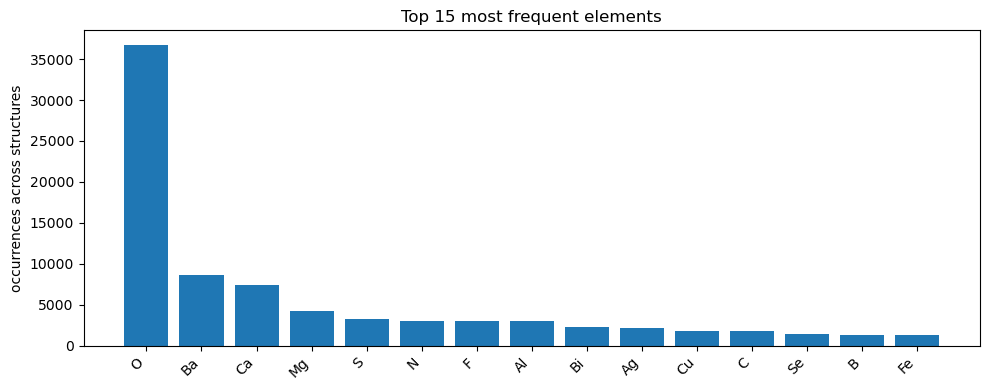

In [7]:
elem_cols = [c for c in df.columns if c.startswith('elem_')]
element_frequency = df[elem_cols].sum(axis=0).sort_values(ascending=False)
top15 = element_frequency.head(15)
print(top15)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(top15)), top15.values)
ax.set_xticks(range(len(top15)))
ax.set_xticklabels([c.replace('elem_', '') for c in top15.index], rotation=45, ha='right')
ax.set_title('Top 15 most frequent elements')
ax.set_ylabel('occurrences across structures')
plt.tight_layout()
plt.show()

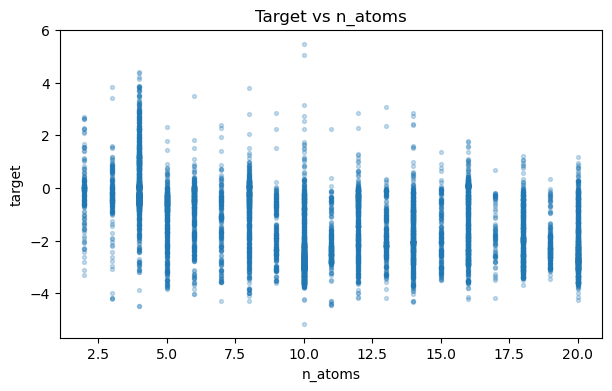

corr(target, n_atoms) = -0.4320


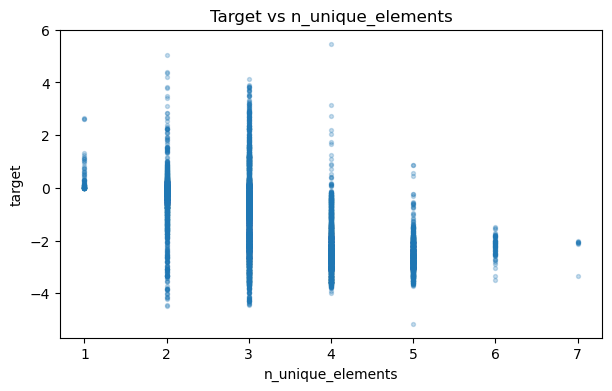

corr(target, n_unique_elements) = -0.5667


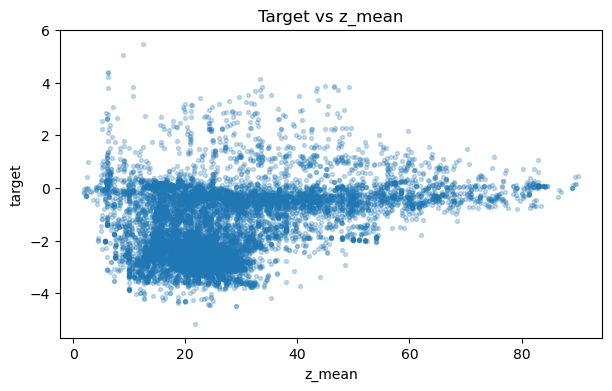

corr(target, z_mean) = 0.3335


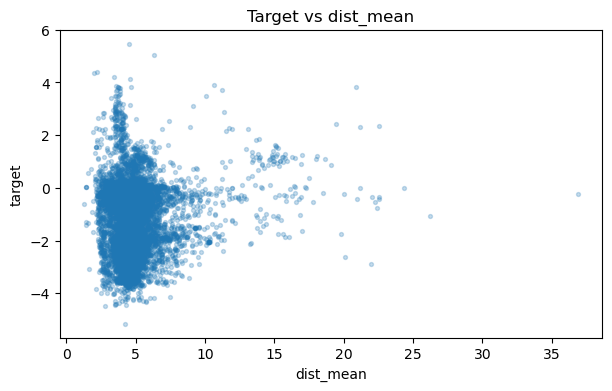

corr(target, dist_mean) = 0.1000


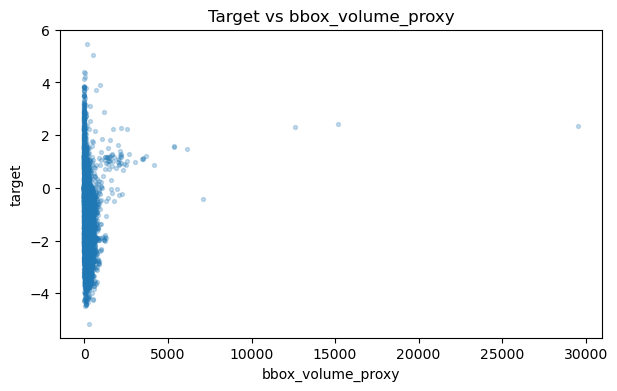

corr(target, bbox_volume_proxy) = 0.0005


In [8]:
for col in ['n_atoms', 'n_unique_elements', 'z_mean', 'dist_mean', 'bbox_volume_proxy']:
    fig, ax = plt.subplots()
    ax.scatter(df[col], df['target'], s=8, alpha=0.25)
    ax.set_title(f'Target vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('target')
    plt.show()
    corr = np.corrcoef(df[col], df['target'])[0, 1]
    print(f'corr(target, {col}) = {corr:.4f}')

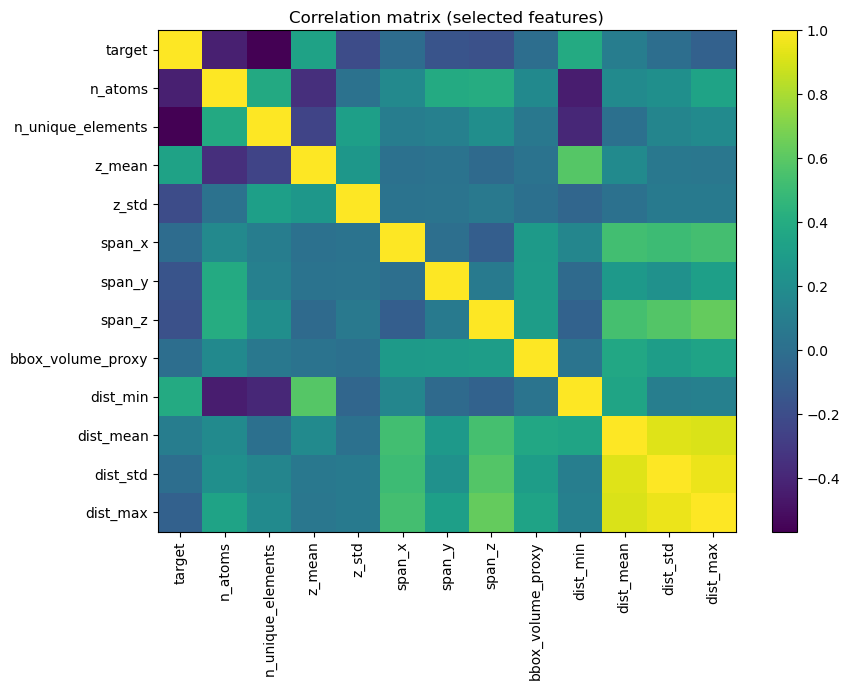

target               1.000000
dist_min             0.393124
z_mean               0.333546
dist_mean            0.100049
bbox_volume_proxy    0.000514
dist_std            -0.002334
span_x              -0.015814
dist_max            -0.078960
span_y              -0.157373
span_z              -0.178884
z_std               -0.201879
n_atoms             -0.432020
n_unique_elements   -0.566717
Name: target, dtype: float64

In [9]:
numeric_cols = ['target', 'n_atoms', 'n_unique_elements', 'z_mean', 'z_std', 'span_x', 'span_y', 'span_z',
                'bbox_volume_proxy', 'dist_min', 'dist_mean', 'dist_std', 'dist_max']
corr = df[numeric_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, aspect='auto')
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
ax.set_title('Correlation matrix (selected features)')
fig.colorbar(im)
plt.tight_layout()
plt.show()

corr['target'].sort_values(ascending=False)

## 6. Challenge evaluation

### Metric choice
The target is continuous, so the main metric should be **MAE (Mean Absolute Error)**.
Why MAE?
- it is easy to interpret,
- it is robust to outliers compared with squared-error metrics,
- it is standard for regression baselines.

### Splitting strategy
A plain random split can be too optimistic when very similar formulas appear in both train and test.
To reduce this leakage risk, this notebook uses a **grouped split by formula**.

That gives a more credible estimate of generalization to unseen compositions.


In [10]:
train_idx, public_idx, private_idx = make_group_splits(df['formula'].values, public_size=0.15, private_size=0.15, random_state=42)
print('Train size  :', len(train_idx))
print('Public size :', len(public_idx))
print('Private size:', len(private_idx))

train_formulas = set(df.iloc[train_idx]['formula'])
public_formulas = set(df.iloc[public_idx]['formula'])
private_formulas = set(df.iloc[private_idx]['formula'])
print('\nFormula overlap checks')
print('train/public overlap :', len(train_formulas & public_formulas))
print('train/private overlap:', len(train_formulas & private_formulas))
print('public/private overlap:', len(public_formulas & private_formulas))

Train size  : 7068
Public size : 1481
Private size: 1451

Formula overlap checks
train/public overlap : 0
train/private overlap: 0
public/private overlap: 0


## 7. Baseline model

In [11]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

feature_cols = get_numeric_feature_columns(df)
X_train = df.iloc[train_idx][feature_cols].to_numpy(dtype=float)
y_train = df.iloc[train_idx]['target'].to_numpy(dtype=float)
X_public = df.iloc[public_idx][feature_cols].to_numpy(dtype=float)
y_public = df.iloc[public_idx]['target'].to_numpy(dtype=float)

naive = DummyRegressor(strategy='mean')
naive.fit(X_train, y_train)
naive_pred = naive.predict(X_public)
print('Naive baseline')
print('  Public MAE:', mean_absolute_error(y_public, naive_pred))
print('  Public R2 :', r2_score(y_public, naive_pred))

Naive baseline
  Public MAE: 1.1520529901349474
  Public R2 : -0.0001073745421560357


In [12]:
model = get_model()
model.fit(X[train_idx], y[train_idx])
public_pred = model.predict(X[public_idx])

print('Materials baseline (submission.py)')
print('  Public MAE:', mean_absolute_error(y[public_idx], public_pred))
print('  Public R2 :', r2_score(y[public_idx], public_pred))

Materials baseline (submission.py)
  Public MAE: 0.4921647461940229
  Public R2 : 0.714314261328596


## 8. Submission format

The provided `submission.py` contains:
- a `MaterialsBaselineRegressor` class,
- a `get_model()` function returning a model compatible with a Codabench ingestion program.

Expected workflow in the challenge:
1. Codabench loads the participant's `submission.py`.
2. It calls `get_model()`.
3. The returned model receives raw structures in `fit(X_train, y_train)` and `predict(X_test)`.


In [13]:
with open('submission.py', 'r', encoding='utf-8') as f:
    print(''.join(f.readlines()[:40]))

import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

from materials_utils import build_feature_table, get_numeric_feature_columns


class MaterialsBaselineRegressor(BaseEstimator, RegressorMixin):
    """Baseline regressor for raw ragged atomic structures."""

    def __init__(self, alphas=None):
        self.alphas = alphas if alphas is not None else np.logspace(-3, 3, 13)

    def fit(self, X, y):
        df, self.elements_ = build_feature_table(X)
        self.feature_columns_ = get_numeric_feature_columns(df)
        X_tab = df[self.feature_columns_].to_numpy(dtype=float)
        self.model_ = make_pipeline(StandardScaler(), RidgeCV(alphas=self.alphas))
        self.model_.fit(X_tab, np.asarray(y, dtype=float))
        return self

    def predict(self, X):
        df, _ = build_feature_table(X, elements=self.elements_)
        X

## 9. Takeaways for the competition page / report

- This is a **regression** challenge.
- The dataset contains **variable-size atomic structures**, so raw samples are ragged.
- A simple featurization already gives a strong improvement over a naive predictor.
- A **grouped split by formula** is more realistic than a random split.
- The included baseline is intentionally simple and fast; stronger models could exploit richer structural information.
